### Pre-Processing and Cleaning
The first parts of my data cleaning are a bit redundant, as they will be done using textProcessing and prepDocuments but due to the large size of the data, I wanted to clean it as much as possible before running those. I also wanted to have a cleaner dataframe to do the named entity recognition and co-mention analysis in part 2.

In [1]:
# Set working directory
setwd("/users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis")
getwd()

# Install packages
libs <- c("tidyverse",
          "rvest",
          "polite",
          "httr",
          "stringr",
          "lubridate",
          "jsonlite",
          "XML",
          "xml2",
          "purrr",
          "quanteda",
         "hunspell",
         "topicmodels",
         "stm",
         "tidytext",
         "spacyr",
         "widyr",
         "igraph",
         "ggraph")

install.packages(setdiff(libs, rownames(installed.packages())))

lapply(libs, library, character.only = TRUE)

[1] "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis"

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘rvest’


The following object is masked from ‘package:readr’:

    guess_encoding



Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten


Package version: 4.3.1
Unicode version: 14.0
ICU version: 71.1

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.


Attaching package: ‘hunspell’


The following object 

[[1]]
 [1] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "repr"      "stats"    
[13] "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

[[2]]
 [1] "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"    
 [7] "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse" "repr"     
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[3]]
 [1] "polite"    "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"    
 [7] "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse"
[13] "repr"      "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[19] "methods"   "base"     

[[4]]
 [1] "httr"      "polite"    "rvest"     "lubridate" "forcats"   "stringr"  
 [7] "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"  
[13] "tidyverse" "repr"      "stats"     "graphics"  "grDevices" "utils"    
[19] "datasets"  "methods"   "base"     

[[5]]
 [1] "httr"      "polite"    "rvest"     "lubridate" "forcats"   "stringr"  
 [7] "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"  
[13] "tidyverse" "repr"      "stats"     "graphics"  "grDevices" "utils"    
[19] "datasets"  "methods"   "base"     

[[6]]
 [1] "httr"      "polite"    "rvest"     "lubridate" "forcats"   "stringr"  
 [7] "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"  
[13] "tidyverse" "repr"      "stats"     "graphics"  "grDevices" "utils"    
[19] "datasets"  "methods"   "base"     

[[7]]
 [1] "jsonlite"  "httr"      "polite"    "rvest"     "lubridate" "forcats"  
 [7] "stringr"   "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"   
[13] "ggplot2"   "tidyverse" "repr"      "stats"     "graphics"  "grDevices"
[19] "utils"     "datasets"  "methods"   "base"     

[[8]]
 [1] "XML"       "jsonlite"  "httr"      "polite"    "rvest"     "lubridate"
 [7] "forcats"   "stringr"   "dplyr"     "purrr"     "readr"     "tidyr"    
[13] "tibble"    "ggplot2"   "tidyverse" "repr"      "stats"     "graphics" 
[19] "grDevices" "utils"     "datasets"  "methods"   "base"     

[[9]]
 [1] "xml2"      "XML"       "jsonlite"  "httr"      "polite"    "rvest"    
 [7] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
[13] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "repr"      "stats"    
[19] "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

[[10]]
 [1] "xml2"      "XML"       "jsonlite"  "httr"      "polite"    "rvest"    
 [7] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
[13] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "repr"      "stats"    
[19] "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

[[11]]
 [1] "quanteda"  "xml2"      "XML"       "jsonlite"  "httr"      "polite"   
 [7] "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"    
[13] "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse" "repr"     
[19] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[25] "base"     

[[12]]
 [1] "hunspell"  "quanteda"  "xml2"      "XML"       "jsonlite"  "httr"     
 [7] "polite"    "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"    
[13] "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse"
[19] "repr"      "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[25] "methods"   "base"     

[[13]]
 [1] "topicmodels" "hunspell"    "quanteda"    "xml2"        "XML"        
 [6] "jsonlite"    "httr"        "polite"      "rvest"       "lubridate"  
[11] "forcats"     "stringr"     "dplyr"       "purrr"       "readr"      
[16] "tidyr"       "tibble"      "ggplot2"     "tidyverse"   "repr"       
[21] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[26] "methods"     "base"       

[[14]]
 [1] "stm"         "topicmodels" "hunspell"    "quanteda"    "xml2"       
 [

In [2]:
# Load csvs into jupyter
csvs <- c("/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_01.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_02.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_03.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_04.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_05.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_06.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_07.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_08.csv",
          "/Users/rosalielacroix/Desktop/Master's/Quantitative Text Analysis/epstein_dataset_09.csv")

In [3]:
# Read cvs into one large dataframe
df <- map_dfr(csvs, read_csv)

Rows: 3145 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): url, filename, txt
dbl (2): dataset, has_txt

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 565 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): url, filename, txt
dbl (2): dataset, has_txt

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 62 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): url, filename, txt
dbl (2): dataset, has_txt

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 151 Columns: 5
─

In [4]:
# Remove rows that have less than 200 characters, as they are likely just images without any extractable words
df_filtered <- df %>%
    filter(nchar(txt) > 200)

In [5]:
# Remove non-alphanumeric characters
df_filtered <- df_filtered %>%
  mutate(txt = str_replace_all(txt, "[^a-zA-Z\\s]", ""))

In [6]:
# Take out rows that do not have at least 10 words with more than 4 characters
df_filtered <- df_filtered %>%
  filter(sapply(txt, function(x) {
    words <- unlist(strsplit(x, "\\s+"))
    sum(nchar(words) >= 4) > 10  # at least 10 words with 4+ characters
  }))

In [7]:
# Use the hunspell package to take out rows that do not have more than 30% of words
# mispelled, taking out many of the non-dictionary words/word clusters
df_filtered <- df_filtered %>%
  filter(sapply(txt, function(x) {
    words <- unlist(strsplit(x, "\\s+"))
    words <- words[nchar(words) >= 2]  # only check words with 3+ characters
    if(length(words) == 0) return(FALSE)
    mean(!hunspell_check(words)) < 0.6  # keep rows where less than 70% are misspelled
  }))

In [8]:
# Filter the document further using textProcessor, building the corpus for the model, making everything lower case, removing numbers, and stop words
# I chose to use "efta" and "page" as stop words as they were found in nearly every text document due to the fact that they were a marker for the photo/document
df_processed <- textProcessor(
    documents = df_filtered$txt, # Focusing on the text column of the dataframe
    metadata = df_filtered, # Setting the previously filtered dataframe as the metadata
    customstopwords = c("efta", "page", "whereas", "herein", "pursuant", "thereof",
                    "hereof", "shall", "said", "hereby") # Common words found in legal documents that do not hold significant meaning
    )                        

Building corpus... 
Converting to Lower Case... 
Removing punctuation... 
Removing stopwords... 
Remove Custom Stopwords...
Removing numbers... 
Stemming... 
Creating Output... 


In [9]:
# More filtering to specifically prep documents for STM
out <- prepDocuments(
    df_processed$documents,
    df_processed$vocab,
    df_processed$meta,
    lower.thresh = 20 # Drop words that are found less than 20 times within the text
    )

Removing 854351 of 880913 terms (1457205 of 14745468 tokens) due to frequency 
Removing 11 Documents with No Words 
Your corpus now has 98743 documents, 26562 terms and 13288263 tokens.

### Part 1: Modeling Topics

I will be using structured topic modelling to model my topics. I will first run the function searchK() to determine how many topics I should use to model the data. From this I am looking for high held-out likelihood and high semantic coherence. Held-out likelihood is a measure of how well the model is able to predict words in documents it hasn't seen yet, which is therefore an indication of the test set accuracy. Semantic coherence tells me how much the words within each topic actually appear together in the documents. 

After I determined the number of topics I should use in my model, I fit the model without labeled topics. I then read through the words within each topic to determine what they represent, and named the topics accordingly. 

In [10]:
kresult <- searchK(
    out$documents,
    out$vocab,
    K = c(5, 10, 15), # Testing k values of 5, 10, and 15
    data = out$meta,
    seed = 42,
    verbose = TRUE
    )

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Using only 10000 most frequent terms during initialization...
	 Finding anchor words...
 	.....
	 Recovering initialization...
 	....................................................................................................
Initialization complete.
....................................................................................................
Completed E-Step (9 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -7.856) 
....................................................................................................
Completed E-Step (8 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -7.749, relative change = 1.367e-02) 
....................................................................................................
Completed E-Step (8 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -7.709, relative change = 5.

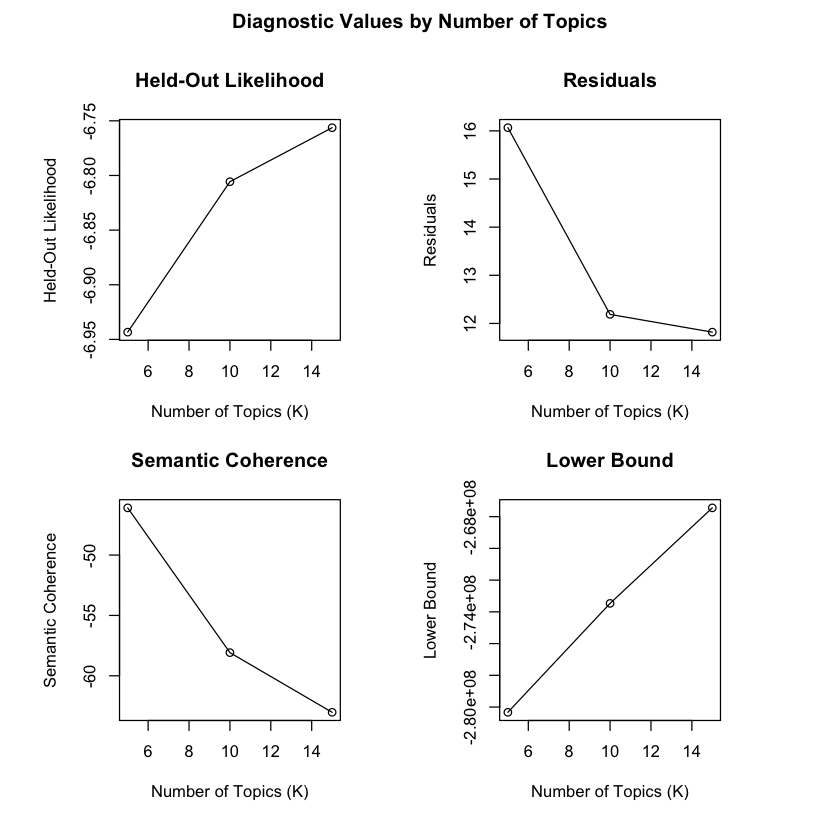

In [11]:
# Create plots with the results kresult
plot(kresult)

It appears that 10 is the optimal number of topics, as it is high in held-out likelihood and though not as high in semantic coherence, it appears to strike the best balance between the two. For my model I will use 10 topics.

In [12]:
# Create model
stm_model <- stm(
  documents = out$documents,
  vocab = out$vocab,
  K = 10, # The number the was determined as the optimal number of topics previously
  init.type = "Spectral", # Controlling the first guess that is made 
  seed = 42, # Set seed
  verbose = TRUE
)

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Using only 10000 most frequent terms during initialization...
	 Finding anchor words...
 	..........
	 Recovering initialization...
 	....................................................................................................
Initialization complete.
....................................................................................................
Completed E-Step (12 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -7.848) 
....................................................................................................
Completed E-Step (14 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -7.290, relative change = 7.101e-02) 
....................................................................................................
Completed E-Step (13 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -7.174, relative cha

In [13]:
# Inspect the topics
labelTopics(stm_model, n = 20)

Topic 1 Top Words:
 	 Highest Prob: may, fund, agreement, person, secur, will, account, invest, includ, compani, busi, target, manag, tax, requir, inform, form, provid, interest, applic 
 	 FREX: piri, truste, partnership, port, alphakey, kadina, grantor, adelaid, executor, estat, arbitr, intellectu, millennium, instrument, owner, escrow, hereto, beneficiari, successor, ownership 
 	 Lift: attorneyinfact, adelaid, aborigin, agrasso, ahpra, aliphcom, alphakey, altimet, arriel, assignor, attorneysatlaw, bandt, baycorp, bequest, blieschk, boval, bradstreet, bulon, buyin, caltex 
 	 Score: agreement, invest, investor, piri, truste, aircraft, interest, alphakey, asset, millennium, polic, partnership, capit, incom, executor, section, grantor, partner, trust, sourc 
Topic 2 Top Words:
 	 Highest Prob: account, date, number, total, payment, servic, charg, new, credit, amount, balanc, card, statement, type, address, day, name, york, fedex, purchas 
 	 FREX: payor, kgs, dda, luel, citibank, catg

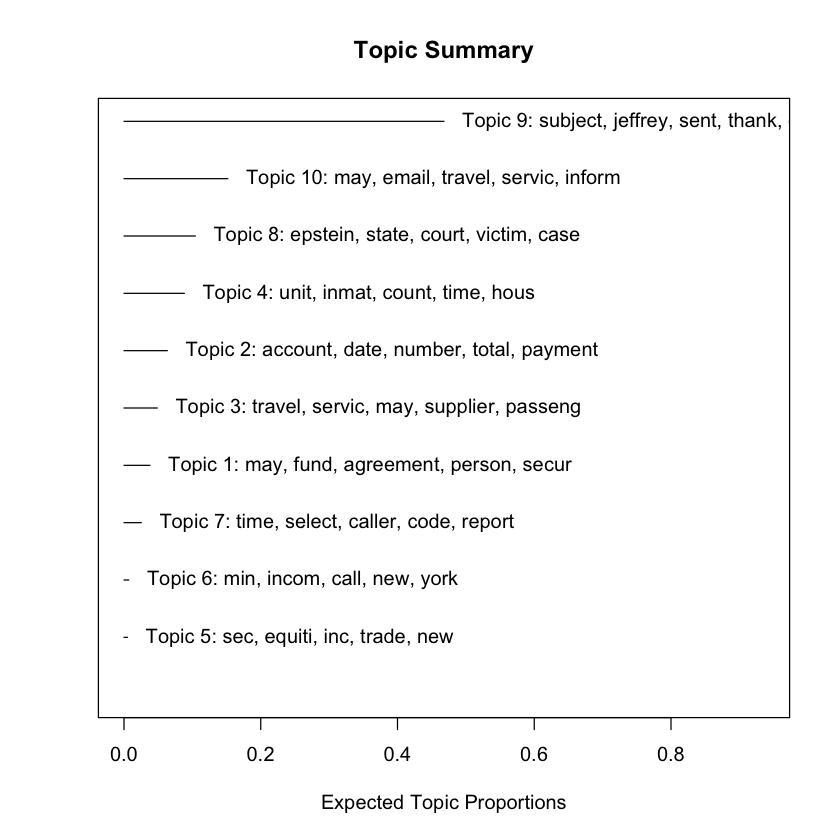

In [14]:
# Plot a visual summary of the topics
plot(stm_model, type = "summary", n = 5, main = "Topic Summary")

In [15]:
# Assign labels to topics
topic_labels <- c(
    "1" = "Financial Communications",
    "2" = "Financial/Payment Records",
    "3" = "Travel Information",
    "4" = "Prison Records",
    "5" = "Financial Investigation",
    "6" = "Phone/Mobile Records",
    "7" = "Political Communications & Call Records",
    "8" = "Court/Legal Proceedings",
    "9" = "Personal Communications & Witness Interviews",
    "10" = "Travel & Legal Correspondence"
)

In [16]:
# Extract topic proportion matrix where each document is a row and each column is a topic, with each cell representing how strongly the document is associated with the topic
topic_props <- make.dt(stm_model, meta = out$meta)

In [17]:
# Define dominant topics and bind them to the dataframe, now labeling the document with the topic that is most strongly associated with it
df_labelled <- out$meta %>%
  bind_cols(topic_props) %>%
  mutate(
      dominant_topic = apply(select(., starts_with("Topic")), 1, which.max),
      dominant_topic_label = topic_labels[as.character(dominant_topic)],
      dominant_topic_prob = apply(select(., starts_with("Topic")), 1, max)
      )

New names:
• `dataset` -> `dataset...1`
• `url` -> `url...2`
• `filename` -> `filename...3`
• `has_txt` -> `has_txt...4`
• `txt` -> `txt...5`
• `dataset` -> `dataset...17`
• `url` -> `url...18`
• `filename` -> `filename...19`
• `has_txt` -> `has_txt...20`
• `txt` -> `txt...21`


In [18]:
# Determine the number of documents assigned to each topic, as well as the average probability for that topic, which is how strongly all of the documents are associated with in that
# topic are associated with it
df_labelled %>%
  group_by(dominant_topic_label) %>%
  summarise(
    n = n(),
    avg_prob = mean(dominant_topic_prob)
  ) %>%
  arrange(desc(n))

dominant_topic_label,n,avg_prob
<chr>,<int>,<dbl>
Personal Communications & Witness Interviews,49417,0.7951954
Travel & Legal Correspondence,15533,0.7155014
Court/Legal Proceedings,9975,0.6831073
Prison Records,8694,0.6511317
Financial/Payment Records,6295,0.6712163
Travel Information,4092,0.9510823
Financial Communications,2538,0.6017716
Political Communications & Call Records,1460,0.4939946
Phone/Mobile Records,410,0.8123940


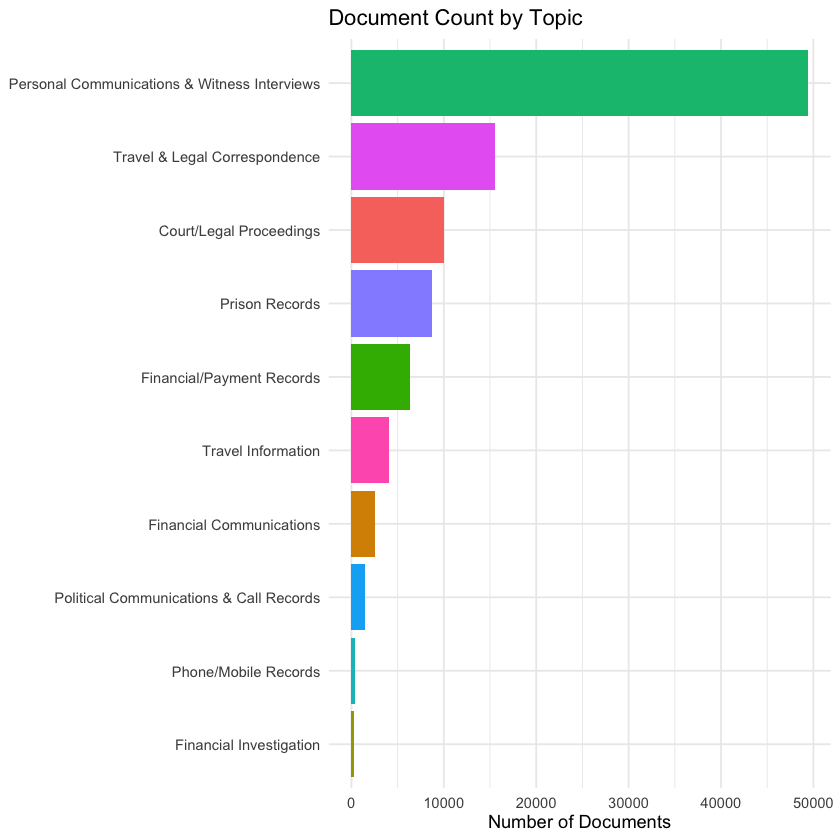

In [19]:
# Plot the number of topics assigned to each topic
df_labelled %>%
  count(dominant_topic_label) %>%
  arrange(desc(n)) %>%
  ggplot(aes(x = reorder(dominant_topic_label, n), y = n, fill = dominant_topic_label)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(title = "Document Count by Topic", x = NULL, y = "Number of Documents") +
  theme_minimal()

### Part 2: Modelling Connections
For this part I am using Named Entity Recognition. I will be using the package "spacyr".

In [20]:
# Initialize spacyr
spacy_initialize(model = "en_core_web_sm")

successfully initialized (spaCy Version: 3.8.11, language model: en_core_web_sm)



I chose to use a sample of 2000 documents from the dataframe.

In [21]:
set.seed(42)
df_sample <- df_filtered %>% sample_n(2000) # Take a sample of 2000 documents from the dataframe

# Reinitialise spacy
reticulate::py_run_string("nlp.max_length = 2000000")

# Process the sample in batches
batch_size <- 50 
batches <- split(df_sample$txt, ceiling(seq_along(df_sample$txt) / batch_size)) # Split the dataframe into batches of size 50, using ceiling() to determine which batch each document is placed in

entities_list <- list() # Initialize empty list where the entities will go

for(i in seq_along(batches)) {
  cat("Starting batch", i, "of", length(batches), "\n") # Message to show that a batch has begun to be parsed
  flush.console()
  
  tryCatch({ # This wraps the process in an error handler, I decided to use this as I was continuously getting errors running the large dataframe and this was recommended from 
              # Sonnet to allow the process to keep running when an error occurs, throwing a warning and moving on to the next document
    batch_entities <- spacy_parse(batches[[i]], entity = TRUE) %>% # Run NER
      entity_extract() %>% # Pull entities
      filter(entity_type == "PERSON") # Ensure only entities that are people placed in this object

    # Ensure document ID is not overrun by the subsequent batch
    batch_entities <- batch_entities %>%
      mutate(doc_id = paste0("text", 
             (i - 1) * batch_size + as.numeric(str_extract(doc_id, "\\d+"))))
    
    entities_list[[i]] <- batch_entities
  }, error = function(e) { # Error message
    cat("Error in batch", i, ":", conditionMessage(e), "\n")
  })
  
  cat("Completed batch", i, "\n") # Message to show batch parsing has completed
  flush.console()
}

entities <- bind_rows(entities_list) # Combining results together

Starting batch 1 of 40 
Completed batch 1 
Starting batch 2 of 40 
Completed batch 2 
Starting batch 3 of 40 
Completed batch 3 
Starting batch 4 of 40 
Completed batch 4 
Starting batch 5 of 40 
Completed batch 5 
Starting batch 6 of 40 
Completed batch 6 
Starting batch 7 of 40 
Completed batch 7 
Starting batch 8 of 40 
Completed batch 8 
Starting batch 9 of 40 
Completed batch 9 
Starting batch 10 of 40 
Completed batch 10 
Starting batch 11 of 40 
Completed batch 11 
Starting batch 12 of 40 
Completed batch 12 
Starting batch 13 of 40 
Completed batch 13 
Starting batch 14 of 40 
Completed batch 14 
Starting batch 15 of 40 
Completed batch 15 
Starting batch 16 of 40 
Completed batch 16 
Starting batch 17 of 40 
Completed batch 17 
Starting batch 18 of 40 
Completed batch 18 
Starting batch 19 of 40 
Completed batch 19 
Starting batch 20 of 40 
Completed batch 20 
Starting batch 21 of 40 
Completed batch 21 
Starting batch 22 of 40 
Completed batch 22 
Starting batch 23 of 40 
Com

In [22]:
# Check the new entities object
head(entities, 20)

# View the most frequently mentioned names
entities %>%
  count(entity, sort = TRUE) %>%
  head(20)

,doc_id,sentence_id,entity,entity_type
,<chr>,<int>,<chr>,<chr>
1,text1,1,Jeffrey,PERSON
2,text1,2,Frederick_P_Rose_Hall,PERSON
3,text1,3,Jeffrey_Epstein,PERSON
4,text1,6,Kram_BE_ _Sent,PERSON
5,text1,6,Christina_Andersson_,PERSON
6,text1,6,JEE,PERSON
7,text2,1,Jeffrey_Epstein,PERSON
8,text2,6,Lesley_ _Sent,PERSON
9,text2,7,Jeffrey_Epstein,PERSON


,entity,n
,<chr>,<int>
1,Epstein,1714
2,Jeffrey_Epstein,1545
3,Lesley_Groff,625
4,Epsteins,620
5,Jeffrey,610
6,TCRF,357
7,Cassell,327
8,Conduct,156
9,Jane_Doe,144


In [23]:
# From my above results, I saw that Jeffrey Epstein, Ghislaine Maxwell, and Lesley Groff were mentioned a number of times in different ways, so I will clean this by merging all of their mentions together
entities_clean <- entities %>%
  mutate(entity = case_when(
    str_detect(entity, regex("jeffrey|epstein|JEE", ignore_case = TRUE)) ~ "Jeffrey Epstein", 
    str_detect(entity, regex("ghislaine|maxwell", ignore_case = TRUE)) ~ "Ghislaine Maxwell",
    str_detect(entity, regex("lesley|groff", ignore_case = TRUE)) ~ "Lesley Groff",
    str_detect(entity, regex("larry|visoski", ignore_case = TRUE)) ~ "Larry Visoski",
    str_detect(entity, regex("jane|doe", ignore_case = TRUE)) ~ "Jane Doe",
    TRUE ~ entity  # keep everything else as is
  ))

In [24]:
# I also saw that there were a large number of entities that were not names, so I will remove those that appeared the most
# Note: I continued updating this list after I ran the code below as new non-names would arise in the top 20
non_names <- c("Larkspur_CA", "TCRF", "Ill", "Refer", "Adobe_Acrobat_Reader_Refer", "Refer",
               "al_sums", "Card", "Conduct", "Suppl_Box", "Chtamstths_V_P", "Email", "Forwarded", "Subject",
              "Jun", "Tues", "JFK", "St_Thomas")

# Filter out non names
entities_clean <- entities_clean %>%
    filter(!entity %in% non_names) 

In [25]:
# Check top 20 most common names
entities_clean %>%
    count(entity, sort = TRUE) %>%
    head(20)

,entity,n
,<chr>,<int>
1,Jeffrey Epstein,5682
2,Lesley Groff,1158
3,Ghislaine Maxwell,417
4,Cassell,327
5,Jane Doe,315
6,Larry Visoski,236
7,Edwards,139
8,Victim,120
9,Minor_Victim,111


In [26]:
# Count how many times each pair of names appears in the same document
co_mentions <- entities_clean %>%
  pairwise_count(entity, doc_id, sort = TRUE) %>% 
  filter(n >= 3)  # only keep pairs that appear together at least 3 times

head(co_mentions, 20)

item1,item2,n
<chr>,<chr>,<dbl>
Lesley Groff,Jeffrey Epstein,428
Jeffrey Epstein,Lesley Groff,428
Larry Visoski,Jeffrey Epstein,67
Jeffrey Epstein,Larry Visoski,67
Larry Visoski,Lesley Groff,44
Lesley Groff,Larry Visoski,44
Ghislaine Maxwell,Jeffrey Epstein,37
Jeffrey Epstein,Ghislaine Maxwell,37
Madison,Jeffrey Epstein,34


In [27]:
# There were a number of dupicate pairs, so I will remove those for my final analysis
co_mentions <- co_mentions %>%
    filter(item1 < item2)

head(co_mentions, 20)

item1,item2,n
<chr>,<chr>,<dbl>
Jeffrey Epstein,Lesley Groff,428
Jeffrey Epstein,Larry Visoski,67
Larry Visoski,Lesley Groff,44
Ghislaine Maxwell,Jeffrey Epstein,37
Jeffrey Epstein,Madison,34
Jeffrey Epstein,Leon,33
Jeffrey Epstein,Mar,27
Leon,Lesley Groff,26
Jane Doe,Jeffrey Epstein,25


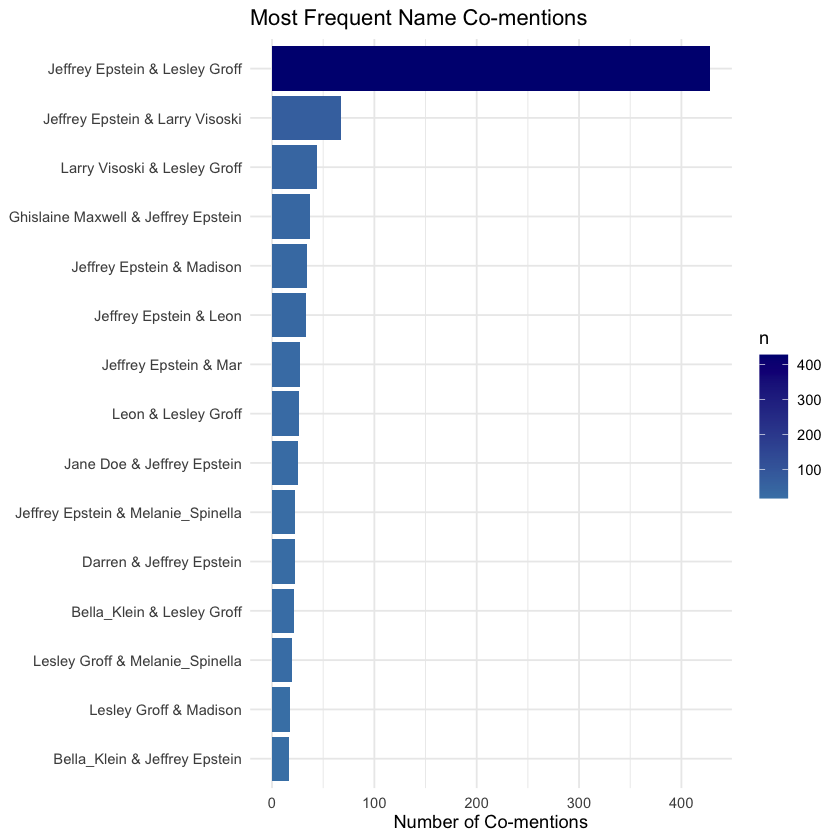

In [28]:
# Bar plot with the top 15 co-mentions
co_mentions %>%
  head(15) %>%
  mutate(pair = paste(item1, "&", item2)) %>%
  ggplot(aes(x = reorder(pair, n), y = n, fill = n)) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(low = "steelblue", high = "navy") +
  labs(title = "Most Frequent Name Co-mentions",
       x = NULL, y = "Number of Co-mentions") +
  theme_minimal()

As it can be seen in both the co-mentions tibble and bar graph, Jeffrey Epstein was most frequently mentioned with Lesley Groff. Their names were associated with one another 428 times throughout the files that were analysed. Groff was Epstein's executive assistant. Epstein and Larry Visoski were next mentioned most frequently together. Larry Visoski was Epstein's pilot. Groff and Visoski were then most freuqnetly mentioned together, likely indicating travel correspondence. Epstein was mentioned a number of times with individuals whose last names were not mentioned. Groff was frequently mentioned with these individuals as well. 

The name "Leon" mentioned could be either Leon Black or Leon Botstein, both of whom Epstein had close contacts with. Melanie Spinella, who is frequently mentioned with both Epstein and Groff was one of Leon Black's executive assistants. I chose to keep "Mar" in due to the fact that I thought it could be in reference to Mar-A-Lago, Donald Trump's resort, but it could also be in reference to the month of March, as "Jun" was one of the non-names that I removed. 

Bella Klein was Epstein's accountant. The name "Darren" is likely in reference to Darren Indyke, who similar to Richard Kahn (17th most frequent co-mention), were within Epstein's inner circle. I was not able to determine who "Madison" is likely in reference to.